# <center>Bootstrap and simulation-based inference</center>
### <center>Alfred Galichon (NYU)</center>
## <center>'math+econ+code' masterclass series: econometrics</center>
#### <center>With python code examples</center>

© 2018–2026 by Alfred Galichon. Past and present support from NSF grant DMS-1716489, ERC grant CoG-866274 are acknowledged, as well as inputs from contributors listed [here](http://www.math-econ-code.org/team).

**If you reuse material from this masterclass, please cite as:**<br>
Alfred Galichon, 'math+econ+code' masterclass series. https://www.math-econ-code.org/

### Learning objectives

* State the nonparametric bootstrap principle, approximate the sampling distribution of a statistic by its distribution under resampling from the empirical CDF, and recognize the bootstrap as a *plug-in* estimator with the empirical distribution as the plug-in.

* State Efron's bootstrap consistency theorem (informally) and identify the regularity conditions under which it holds: smooth functionals of the empirical CDF, $\sqrt{I}$-consistent estimators with continuous limiting distributions.

* Construct four families of bootstrap confidence intervals, percentile, basic (Hall), studentized (bootstrap-$t$), and bias-corrected accelerated (BCa), and identify which is appropriate when the bootstrap distribution is skewed or biased.

* Implement and apply *variants* of the bootstrap that handle data structures violating the i.i.d. assumption: the **wild bootstrap** (preserving regressor design under heteroskedasticity), the **cluster bootstrap** (resampling clusters rather than observations), and the **block bootstrap** (preserving short-range dependence in time series).

* Recognize and diagnose the canonical *bootstrap failures*: nonregular estimators (max of uniforms), boundary problems, and tail estimation. Use subsampling as an alternative when the bootstrap is inconsistent.

* Synthesize the inference methods from across the course, asymptotic Eicker–White and cluster-robust CR1 (Lecture 4), GLS and its feasible variants (Lecture 5), Hansen $J$ (Lecture 9), IV variance (Lecture 10), DDML influence function (Lecture 13), under the unifying lens of *simulation-based inference*: when an analytical asymptotic distribution is available, use it; when it's not, simulate.

### References

**[H]** Hansen, B. E. (2022). *Econometrics*. Princeton University Press. Chapter 11.

**[E]** Efron, B. (1979). 'Bootstrap Methods: Another Look at the Jackknife'. *Annals of Statistics*, 7(1), 1–26.

**[BF]** Bickel, P. J., and Freedman, D. A. (1981). 'Some Asymptotic Theory for the Bootstrap'. *Annals of Statistics*, 9(6), 1196–1217.

**[Hal]** Hall, P. (1992). *The Bootstrap and Edgeworth Expansion*. Springer.

**[MWe]** MacKinnon, J. G., and Webb, M. D. (2017). 'Wild Bootstrap Inference for Wildly Different Cluster Sizes'. *Journal of Applied Econometrics*, 32(2), 233–254.

**[CGM08]** Cameron, A. C., Gelbach, J. B., and Miller, D. L. (2008). 'Bootstrap-Based Improvements for Inference with Clustered Errors'. *Review of Economics and Statistics*, 90(3), 414–427.

**[PRW]** Politis, D. N., Romano, J. P., and Wolf, M. (1999). *Subsampling*. Springer.

# Motivation: when asymptotic theory isn't enough

* Every estimator we have developed in this course, OLS, IV, GMM, MLE, DDML, comes with an asymptotic normal distribution and a corresponding standard error. Wald intervals and tests built on this asymptotic theory are standard tools in applied econometrics.

* But asymptotic approximations can be unreliable in finite samples, especially when the estimator is nonlinear, when residuals are heavily skewed, when the data are clustered or serially dependent, when instruments are weak, or when the parameter of interest sits near a boundary. The empirical record is full of asymptotic intervals with poor finite-sample coverage and tests with severe size distortions.

* The bootstrap (Efron 1979) offers a route to inference that bypasses the asymptotic approximation altogether: simulate the sampling distribution of $\hat\theta$ by resampling from the data. When it works, the bootstrap typically gives more accurate finite-sample coverage than the Wald interval and extends to settings (cluster, panel, weakly dependent) where the analytical asymptotic distribution is complex or unknown.

* This lecture develops the bootstrap as the second leg of the inference toolkit, alongside the asymptotic theory from Lectures 1–11. We will see when each is preferable, how to combine them, and where the bootstrap itself fails: closing the inference story for the course.

## Loading our libraries and data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from types import SimpleNamespace
import linearmodels.iv as iv

rng = np.random.default_rng(777)
plt.rcParams['figure.figsize'] = (8, 4.5)


In [2]:
url = 'https://vincentarelbundock.github.io/Rdatasets/csv/sampleSelection/Mroz87.csv'
try:
    mroz = pd.read_csv(url)                       # Rdatasets Mroz87 (needs a network)
except Exception:
    # Offline fallback: the identical Mroz (1987) data ships with the `wooldridge` package.
    import wooldridge
    mroz = (wooldridge.data('mroz')
            .rename(columns={'inlf': 'lfp', 'kidslt6': 'kids5', 'kidsge6': 'kids618'})
            .copy())
mroz_w = mroz.loc[mroz['lfp'] == 1].copy()
mroz_w['lwage'] = np.log(mroz_w['wage'])
I = len(mroz_w)

y_i = mroz_w['lwage'].values
X_i_k = np.column_stack([
    np.ones(I),
    mroz_w['educ'].values,
    mroz_w['exper'].values,
    mroz_w['exper'].values ** 2,
])
Z_i_l = np.column_stack([
    np.ones(I),
    mroz_w['motheduc'].values,
    mroz_w['fatheduc'].values,
    mroz_w['exper'].values,
    mroz_w['exper'].values ** 2,
])
xnames = ['const', 'educ', 'exper', 'exper^2']
print(f'I = {I}')


I = 428


# 1. The nonparametric bootstrap

## 1.1 The bootstrap principle

Let $\{Z_1,\dots,Z_I\}$ be an i.i.d. sample from an unknown distribution $F$, and let $\hat\theta_I = T(F_I)$ be a statistic computed from the empirical CDF $F_I$. We want to know the sampling distribution of $\hat\theta_I$: or some functional of it (the SE, a CI, a $p$-value).

The **bootstrap** estimates this sampling distribution by treating $F_I$ as if it were the truth and resampling from it. Concretely:

1. Draw a bootstrap sample $\{Z_1^*,\dots,Z_I^*\}$ by sampling $I$ observations from the data *with replacement*.
2. Compute $\hat\theta_I^* := T(F_I^*)$ on the bootstrap sample.
3. Repeat steps 1–2 for $b = 1,\dots,B$ replications.

The empirical distribution of $\{\hat\theta_I^{*1},\dots,\hat\theta_I^{*B}\}$ is the bootstrap estimate of the sampling distribution of $\hat\theta_I$.

## 1.2 The plug-in interpretation

The bootstrap is a *plug-in* estimator: the sampling distribution of $\hat\theta_I$ is a functional $H(F) := \mathcal{L}_F\bigl(\sqrt{I}(\hat\theta_I - \theta(F))\bigr)$, and the bootstrap replaces $F$ with $F_I$:
$$
H(F_I) \approx H(F)\quad\text{when }F_I\to F.
$$
By the Glivenko–Cantelli theorem, $F_I\to F$ uniformly, so as long as $H$ is continuous in $F$ (in a suitable topology), $H(F_I)\to H(F)$: the bootstrap is consistent.

## 1.3 DIY implementation

In [3]:
def bootstrap_estimator(estimator_fn, data, B=1_000, rng=None):
    r"""Generic nonparametric bootstrap: pass any function that takes a resampled data
    array and returns a scalar (or vector) statistic.

    All B draws are genuine resamples. The statistic on the original sample is returned
    alongside them, never *inside* them: putting $\hat\theta$ into the bootstrap array
    would contaminate every quantile computed from it.
    """
    if rng is None:
        rng = np.random.default_rng()
    I = data.shape[0] if hasattr(data, 'shape') else len(data)
    sample_stat = np.atleast_1d(estimator_fn(data))
    out = np.empty((B,) + sample_stat.shape)
    for b in range(B):
        idx = rng.integers(0, I, size=I)
        out[b] = estimator_fn(data[idx] if hasattr(data, '__getitem__') else [data[i] for i in idx])
    return SimpleNamespace(boot=out, stat=sample_stat, B=B)

# Quick sanity check: bootstrap the mean of standard-normal data
rng = np.random.default_rng(42)
data = rng.standard_normal(200)
fit_boot = bootstrap_estimator(np.mean, data, B=2000, rng=rng)
boot_means = fit_boot.boot
print(f'Sample mean                 = {data.mean():.4f}')
print(f'Bootstrap mean of means     = {boot_means.mean():.4f}')
print(f'Bootstrap SE of mean        = {boot_means.std(ddof=1):.4f}')
print(f'Theoretical SE: σ/√I        = {1/np.sqrt(200):.4f}')
print(f'\ngenuine resamples drawn   = {fit_boot.B}  (none of them the original sample)')

# Verification contract. The shape check is necessary but not sufficient: the bug this routine
# used to have produced an array of exactly the right length whose first entry was the
# original-sample statistic rather than a resample. Comparing *values* cannot detect that —
# an inserted statistic is only caught if it happens to differ numerically from every
# resample, and for a discrete statistic a resample may legitimately reproduce the sample
# value. So test at the level of what the routine actually passes to the estimator.
assert boot_means.shape[0] == 2000, f'expected 2000 resamples, got {boot_means.shape[0]}'

seen_calls = []
def spy_mean(a_i):
    """Records every array handed to it, then behaves like np.mean."""
    seen_calls.append(np.asarray(a_i).copy())
    return np.mean(a_i)

B_probe = 25
probe_i = np.random.default_rng(99).standard_normal(50)
fit_probe = bootstrap_estimator(spy_mean, probe_i, B=B_probe,
                                rng=np.random.default_rng(0))

# One evaluation on the original sample (for .stat), then exactly B on resamples.
assert len(seen_calls) == 1 + B_probe, f'estimator called {len(seen_calls)} times'
assert np.array_equal(seen_calls[0], probe_i), 'the first call is not the original sample'
assert fit_probe.boot.shape[0] == B_probe

# The decisive check: output row b must be the statistic of resample call b, so row 0 holds a
# RESAMPLE and not the original sample. Under the old implementation this failed at b = 0.
for b in range(B_probe):
    assert np.isclose(fit_probe.boot[b], np.mean(seen_calls[1 + b])), \
        f'output row {b} does not correspond to resample call {b}'
print(f'index-level check: {B_probe} resample calls, output row 0 is a resample '
      f'(not the sample statistic)')

# Cross-check the bootstrap standard error against an independent implementation.
sp_boot = stats.bootstrap((data,), np.mean, n_resamples=2000, method='percentile',
                          random_state=np.random.default_rng(4321))
se_ours, se_scipy = boot_means.std(ddof=1), sp_boot.standard_error
print(f'bootstrap SE, ours = {se_ours:.5f};  scipy.stats.bootstrap = {se_scipy:.5f};  '
      f'ratio = {se_ours/se_scipy:.4f}')
assert abs(se_ours / se_scipy - 1) < 0.10, 'bootstrap SE disagrees with scipy by >10%'
print('Verification passed: B genuine resamples, and the SE matches an independent bootstrap.')


Sample mean                 = -0.0305
Bootstrap mean of means     = -0.0317
Bootstrap SE of mean        = 0.0643
Theoretical SE: σ/√I        = 0.0707

genuine resamples drawn   = 2000  (none of them the original sample)
index-level check: 25 resample calls, output row 0 is a resample (not the sample statistic)
bootstrap SE, ours = 0.06434;  scipy.stats.bootstrap = 0.06159;  ratio = 1.0446
Verification passed: B genuine resamples, and the SE matches an independent bootstrap.


# 2. Bootstrap confidence intervals

There are several ways to convert the bootstrap distribution into a $(1-\alpha)$ CI for $\theta$. Under the standard smooth conditions of §1 they are all **first-order** equivalent: percentile, basic and the ordinary normal interval share the same asymptotic coverage, and differences between them vanish as $I$ grows. What separates them is *higher-order* accuracy: the studentized and BCa intervals are second-order accurate, with coverage error $O(I^{-1})$ rather than the $O(I^{-1/2})$ of the percentile and basic intervals, and it is in skewed or heteroskedastic problems at moderate $I$ that the gap shows up. Choosing among them is therefore a finite-sample question, not an asymptotic one.

## 2.1 Percentile interval

The simplest: take the $\alpha/2$ and $1-\alpha/2$ quantiles of the bootstrap distribution directly.
$$
\mathrm{CI}^{\text{pct}}_{1-\alpha} = \bigl[\hat\theta^*_{(\alpha/2)},\;\hat\theta^*_{(1-\alpha/2)}\bigr].
$$
The percentile interval requires no symmetry assumption. Its appeal is **transformation-equivariance**: if $\phi$ is monotone, the percentile interval for $\phi(\theta)$ is exactly $\phi$ applied to the endpoints of the interval for $\theta$, so the answer does not depend on whether one works with $\sigma$ or $\log\sigma$. Its weakness is bias: it is centred on the bootstrap distribution of $\hat\theta^*$ rather than on a pivot, so if $\hat\theta$ is biased the interval inherits that bias rather than correcting it. Its coverage error is $O(I^{-1/2})$.

## 2.2 Basic (Hall) interval

Reflects the percentile interval about the point estimate. The reflection is not a skewness correction, it follows from treating $\hat\theta - \theta$ as the quantity whose distribution the bootstrap approximates, and inverting that directly:
$$
\mathrm{CI}^{\text{basic}}_{1-\alpha} = \bigl[2\hat\theta - \hat\theta^*_{(1-\alpha/2)},\;2\hat\theta - \hat\theta^*_{(\alpha/2)}\bigr].
$$
Unlike the percentile interval it is not transformation-equivariant: reflecting about
$\hat\theta$ on the $\theta$ scale is not the same operation as reflecting on the $\log\theta$
scale, so the two disagree about which parametrisation to trust. It shares the percentile
interval's $O(I^{-1/2})$ coverage error, and it is *not* systematically more accurate under
skewness, neither interval is second-order accurate, and which of the two happens to cover
better in a given skewed problem is not settled by the reflection.

## 2.3 Studentized (bootstrap-$t$) interval

The most accurate of the three for smooth estimators. Compute a *pivotal* statistic $T_b = (\hat\theta^*_b - \hat\theta)/\widehat{\mathrm{SE}}(\hat\theta^*_b)$ for each bootstrap replication, then use its quantiles to construct
$$
\mathrm{CI}^{\text{stud}}_{1-\alpha} = \bigl[\hat\theta - T^*_{(1-\alpha/2)}\,\widehat{\mathrm{SE}}(\hat\theta),\;\hat\theta - T^*_{(\alpha/2)}\,\widehat{\mathrm{SE}}(\hat\theta)\bigr].
$$
Requires that $\widehat{\mathrm{SE}}(\hat\theta^*_b)$ be computable for each bootstrap sample: straightforward for OLS but more involved for nonlinear estimators (often requires a *nested* bootstrap or asymptotic SE within each bootstrap rep).

## 2.4 Bias-corrected accelerated (BCa)

A more sophisticated method that corrects for both bias (median of the bootstrap
distribution off from $\hat\theta$) and skewness; see Efron (1987). Second-order accurate like
the studentized interval, transformation-equivariant like the percentile interval, and it does
not require an SE estimator. We do not implement BCa here; it is the default in many software
packages.

---

**Summarising what actually separates the four.** All are first-order valid under the
conditions of §1, so the choice is about finite-sample behaviour along three axes:

| | equivariant under monotone $\phi$ | needs an SE per resample | coverage error |
| :-- | :-- | :-- | :-- |
| percentile | yes | no | $O(I^{-1/2})$ |
| basic (Hall) | no | no | $O(I^{-1/2})$ |
| studentized | no | yes | $O(I^{-1})$ |
| BCa | yes | no | $O(I^{-1})$ |

The gain in the last column comes from **pivotality**: studentizing removes the unknown scale
from the quantity being bootstrapped, so the bootstrap approximates the distribution of
something that no longer depends on the parameter. BCa buys the same order differently, by
estimating a bias-correction and an acceleration constant from the data. Symmetry appears
nowhere in this table, which is the point: it is not the dividing line.

In [4]:
def bootstrap_cis(boot, θ_hat, α=0.05, se_hat=None, boot_se=None):
    # boot: array of B bootstrap estimates of θ
    # se_hat: SE estimate from the original sample (for studentized CI)
    # boot_se: array of B bootstrap SE estimates (for studentized CI)
    α_lo, α_hi = α/2, 1 - α/2
    q_lo = np.quantile(boot, α_lo)
    q_hi = np.quantile(boot, α_hi)
    out = {
        'percentile': (q_lo, q_hi),
        'basic':      (2*θ_hat - q_hi, 2*θ_hat - q_lo),
    }
    if se_hat is not None and boot_se is not None:
        t_boot = (boot - θ_hat) / boot_se
        t_lo = np.quantile(t_boot, α_lo)
        t_hi = np.quantile(t_boot, α_hi)
        out['studentized'] = (θ_hat - t_hi*se_hat, θ_hat - t_lo*se_hat)
    return out


# 3. Bootstrap CI for the Mroz IV return to schooling

We return to the Mroz IV regression from Lecture 10. The 2SLS estimator was $\hat\beta_{\text{educ}} \approx 0.061$ with asymptotic SE $\approx 0.033$. We now bootstrap the IV estimator and construct percentile, basic, and studentized intervals.

In [5]:
def iv_2sls(X_i_k, y_i, Z_i_l):
    PZX_i_k = Z_i_l @ np.linalg.solve(Z_i_l.T @ Z_i_l, Z_i_l.T @ X_i_k)
    β_k    = np.linalg.solve(X_i_k.T @ PZX_i_k, PZX_i_k.T @ y_i)
    εhat_i = y_i - X_i_k @ β_k
    return β_k, εhat_i

def iv_2sls_with_se(X_i_k, y_i, Z_i_l):
    β_k, εhat_i = iv_2sls(X_i_k, y_i, Z_i_l)
    PZX_i_k = Z_i_l @ np.linalg.solve(Z_i_l.T @ Z_i_l, Z_i_l.T @ X_i_k)
    # Heteroskedasticity-consistent SE (HC0)
    XPZXinv_k_k = np.linalg.inv(X_i_k.T @ PZX_i_k)
    S_k_k = (PZX_i_k * (εhat_i**2)[:, None]).T @ PZX_i_k
    V_k_k = XPZXinv_k_k @ S_k_k @ XPZXinv_k_k
    return β_k, np.sqrt(np.diag(V_k_k))

β_2sls, seasy_k = iv_2sls_with_se(X_i_k, y_i, Z_i_l)
print(f'Sample 2SLS β̂_educ      = {β_2sls[1]:.4f}')
print(f'Asymptotic SE (HC0)     = {seasy_k[1]:.4f}')
print(f'Asymptotic 95% CI       = [{β_2sls[1] - 1.96*seasy_k[1]:.4f}, '
      f'{β_2sls[1] + 1.96*seasy_k[1]:.4f}]')


Sample 2SLS β̂_educ      = 0.0614
Asymptotic SE (HC0)     = 0.0332
Asymptotic 95% CI       = [-0.0036, 0.1264]


In [6]:
# Bootstrap the IV estimator (resample full rows of (X_i_k, Z_i_l, y_i) together)
rng = np.random.default_rng(2026)
B = 2_000
β_boot   = np.empty(B)
se_boot  = np.empty(B)
for b in range(B):
    idx = rng.integers(0, I, size=I)
    β_b, se_b = iv_2sls_with_se(X_i_k[idx], y_i[idx], Z_i_l[idx])
    β_boot[b]  = β_b[1]
    se_boot[b] = se_b[1]

cis = bootstrap_cis(β_boot, β_2sls[1], α=0.05, se_hat=seasy_k[1], boot_se=se_boot)

print(f"{'Method':<22s}{'CI lower':>10s}{'CI upper':>10s}{'width':>10s}")
ci_asy = (β_2sls[1] - 1.96*seasy_k[1], β_2sls[1] + 1.96*seasy_k[1])
print(f'{"Asymptotic Wald":<22s}{ci_asy[0]:>10.4f}{ci_asy[1]:>10.4f}{ci_asy[1]-ci_asy[0]:>10.4f}')
for name, ci in cis.items():
    print(f'{"Bootstrap " + name:<22s}{ci[0]:>10.4f}{ci[1]:>10.4f}{ci[1]-ci[0]:>10.4f}')


Method                  CI lower  CI upper     width
Asymptotic Wald          -0.0036    0.1264    0.1301
Bootstrap percentile     -0.0055    0.1264    0.1319
Bootstrap basic          -0.0036    0.1283    0.1319
Bootstrap studentized    -0.0109    0.1191    0.1300


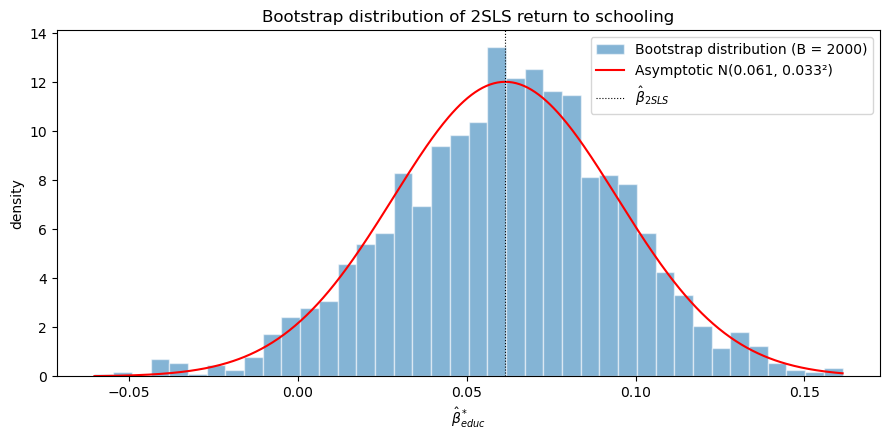

In [7]:
# Visualize bootstrap distribution vs implied asymptotic normal
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(β_boot, bins=40, density=True, alpha=0.55, edgecolor='white',
        label=f'Bootstrap distribution (B = {B})')
xs = np.linspace(β_boot.min(), β_boot.max(), 400)
ax.plot(xs, stats.norm.pdf(xs, loc=β_2sls[1], scale=seasy_k[1]),
        color='red', lw=1.5, label=f'Asymptotic N({β_2sls[1]:.3f}, {seasy_k[1]:.3f}²)')
ax.axvline(β_2sls[1], color='k', ls=':', lw=0.8, label=r'$\hat\beta_{2SLS}$')
ax.set_xlabel(r'$\hat\beta_{educ}^*$')
ax.set_ylabel('density')
ax.set_title(r'Bootstrap distribution of 2SLS return to schooling')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()


The bootstrap distribution closely matches the asymptotic normal in this case: the IV estimator on Mroz is well-behaved at $I = 428$, so asymptotic and bootstrap inference agree. The three bootstrap CIs (percentile, basic, studentized) are nearly identical to each other and to the Wald CI: typical when the sampling distribution is approximately symmetric and unbiased.

# 4. The wild bootstrap

## 4.1 Why a different bootstrap?

The nonparametric (pairs) bootstrap resamples rows of the data, treating both $X$ and $y$ as random. When $X$ is "fixed by design", say, an experiment, or a regression with no measurement error in regressors, resampling $X$ introduces extraneous variation that doesn't reflect the relevant uncertainty.

The *residual* bootstrap fixes $X$ and resamples residuals: $y_i^* = x_i^\top\hat\beta + \hat\varepsilon^*_i$, where $\hat\varepsilon^*$ is drawn from the empirical distribution of $\hat\varepsilon$. This preserves the design but is valid only under homoskedasticity.

The **wild bootstrap** (Wu 1986; Liu 1988; Mammen 1993) fixes $X$ *and* preserves the heteroskedastic structure of the residuals. For each observation, multiply $\hat\varepsilon_i$ by an independent mean-zero random weight $w_i$:
$$
y_i^* = x_i^\top\hat\beta + w_i\,\hat\varepsilon_i.
$$
A simple choice is the Rademacher distribution: $w_i\in\{-1,+1\}$ with equal probability. This satisfies $\mathbb{E}[w] = 0$, $\mathbb{E}[w^2] = 1$, $\mathbb{E}[w^3] = 0$: enough for asymptotic validity in symmetric cases.

## 4.2 Application: heteroskedastic regression coverage

We simulate from a regression with strong heteroskedasticity (residual variance proportional to $x_1^2$) and compare the coverage of:

* Asymptotic CI based on the homoskedastic OLS SE
* Asymptotic CI based on HC1 robust SE
* Wild bootstrap CI

In [8]:
def simulate_het(I=200, β_k=np.array([1.0, 0.5]), rng=None):
    if rng is None:
        rng = np.random.default_rng()
    X_i_k = np.column_stack([np.ones(I), rng.standard_normal(I)])
    σ_i = 0.5 * np.abs(X_i_k[:, 1])                     # strong heteroskedasticity
    ε_i = σ_i * rng.standard_normal(I)
    y_i = X_i_k @ β_k + ε_i
    return X_i_k, y_i

def ols_with_ses(X_i_k, y_i):
    β_k = np.linalg.solve(X_i_k.T @ X_i_k, X_i_k.T @ y_i)
    εhat_i = y_i - X_i_k @ β_k
    I, K = X_i_k.shape
    # Classical (homoskedastic) SE
    σ2 = (εhat_i @ εhat_i) / (I - K)
    Vhom_k_k = σ2 * np.linalg.inv(X_i_k.T @ X_i_k)
    # HC1 robust SE
    XtXinv_k_k = np.linalg.inv(X_i_k.T @ X_i_k)
    Ω_k_k = (X_i_k * (εhat_i ** 2)[:, None]).T @ X_i_k
    Vhc1_k_k = (I / (I - K)) * XtXinv_k_k @ Ω_k_k @ XtXinv_k_k
    return β_k, np.sqrt(np.diag(Vhom_k_k)), np.sqrt(np.diag(Vhc1_k_k)), εhat_i

def wild_bootstrap_ols(X_i_k, y_i, β_hat, εhat_i, B=499, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    I = len(y_i)
    β_boot = np.empty((B, X_i_k.shape[1]))
    XtXinv_k_k = np.linalg.inv(X_i_k.T @ X_i_k)
    Xy_part = X_i_k.T  # so y_boot.T @ Xy_part... etc. just compute on the fly
    for b in range(B):
        w_i = rng.choice([-1.0, 1.0], size=I)            # Rademacher weights
        yboot_i = X_i_k @ β_hat + w_i * εhat_i
        β_boot[b] = XtXinv_k_k @ (X_i_k.T @ yboot_i)
    return β_boot

# Monte Carlo coverage check
rng = np.random.default_rng(2026)
M = 1_000
true_β = np.array([1.0, 0.5])
cov_hom = np.zeros(2)
cov_hc1 = np.zeros(2)
cov_wb  = np.zeros(2)
for m in range(M):
    X_i_k, y_i = simulate_het(I=200, β_k=true_β, rng=rng)
    β_k, sehom_k, sehc1_k, εhat_i = ols_with_ses(X_i_k, y_i)
    # Asymptotic CIs
    ci_hom = np.column_stack([β_k - 1.96 * sehom_k, β_k + 1.96 * sehom_k])
    ci_hc1 = np.column_stack([β_k - 1.96 * sehc1_k, β_k + 1.96 * sehc1_k])
    # Wild bootstrap CI (percentile)
    β_boot = wild_bootstrap_ols(X_i_k, y_i, β_k, εhat_i, B=399, rng=rng)
    q_lo, q_hi = np.quantile(β_boot, [0.025, 0.975], axis=0)
    cov_hom += (ci_hom[:, 0] <= true_β) & (true_β <= ci_hom[:, 1])
    cov_hc1 += (ci_hc1[:, 0] <= true_β) & (true_β <= ci_hc1[:, 1])
    cov_wb  += (q_lo        <= true_β) & (true_β <= q_hi)

cov_hom /= M; cov_hc1 /= M; cov_wb /= M

print(f'Heteroskedastic DGP, I = 200, target coverage = 95%:')
print(f"{'parameter':<10s}{'OLS (classical)':>18s}{'HC1':>10s}{'Wild boot (pct)':>18s}")
for j, name in enumerate(['β_0 (const)', 'β_1 (slope)']):
    print(f'{name:<10s}{cov_hom[j]:>18.3f}{cov_hc1[j]:>10.3f}{cov_wb[j]:>18.3f}')


Heteroskedastic DGP, I = 200, target coverage = 95%:
parameter    OLS (classical)       HC1   Wild boot (pct)
β_0 (const)             0.949     0.945             0.940
β_1 (slope)             0.726     0.942             0.929


The classical OLS SE under-covers: at $I = 200$ with this heteroskedasticity, the nominal 95% Wald CI covers the true slope only $\sim 73\%$ of the time. HC1 and the wild bootstrap both correct the problem to within a few percentage points of nominal coverage ($\sim 93$–$94\%$). HC1 has the advantage of being a closed-form computation; the wild bootstrap has the advantage of extending to settings (clustering, multi-stage estimators, nonlinear functionals) where the analytical robust SE is harder to compute. In a regression where both are available, they are essentially interchangeable.

# 5. The cluster bootstrap

When observations are correlated within clusters (firms, classrooms, individuals × time), resampling individual rows breaks the within-cluster dependence and produces SEs that are too small: the same issue we encountered with CR1 in Lecture 4. The **cluster bootstrap** (Cameron, Gelbach, and Miller 2008) preserves the cluster structure by resampling entire *clusters* with replacement.

## 5.1 Algorithm

1. Let $\mathcal{C}_1,\dots,\mathcal{C}_G$ be the $G$ clusters in the data.
2. Draw $G$ clusters from $\{\mathcal{C}_1,\dots,\mathcal{C}_G\}$ *with replacement*.
3. Pool all observations from the sampled clusters to form a bootstrap sample (which may have fewer or more total observations than $I$).
4. Recompute the estimator on the bootstrap sample.

This automatically inflates the bootstrap variance to reflect within-cluster correlation, with no need for the explicit CR1 formula.

## 5.2 Application

We adapt the clustered design of Lecture 4, §4.4: $G = 50$ clusters of size $n_g = 30$ each, with cluster-constant regressor and equicorrelated errors $\rho = 0.5$. We compute coverage of three CI methods.

In [9]:
def simulate_clustered(G=50, I_g=30, β_k=1.0, ρ=0.5, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    I = G * I_g
    cluster_id = np.repeat(np.arange(G), I_g)
    # Cluster-level common shock (cluster-constant regressor)
    x_g = rng.standard_normal(G)
    X_i_k = np.column_stack([np.ones(I), np.repeat(x_g, I_g)])
    # Within-cluster equicorrelated errors: ε_i = √ρ · u_g + √(1-ρ) · v_i
    u_g = rng.standard_normal(G)
    v_i   = rng.standard_normal(I)
    ε_i   = np.sqrt(ρ) * np.repeat(u_g, I_g) + np.sqrt(1 - ρ) * v_i
    y_i   = X_i_k @ np.array([0.0, β_k]) + ε_i
    return X_i_k, y_i, cluster_id

def ols_clustered_ses(X_i_k, y_i, cluster_id):
    β_k = np.linalg.solve(X_i_k.T @ X_i_k, X_i_k.T @ y_i)
    εhat_i = y_i - X_i_k @ β_k
    I, K = X_i_k.shape
    XtXinv_k_k = np.linalg.inv(X_i_k.T @ X_i_k)
    # Classical (homoskedastic) SE
    σ2 = (εhat_i @ εhat_i) / (I - K)
    sehom_k = np.sqrt(np.diag(σ2 * XtXinv_k_k))
    # CR1 cluster-robust SE
    G = len(np.unique(cluster_id))
    S_k_k = np.zeros((K, K))
    for g in np.unique(cluster_id):
        idx = (cluster_id == g)
        Xg_i_k, εg_i = X_i_k[idx], εhat_i[idx]
        Xε_g = Xg_i_k.T @ εg_i
        S_k_k += np.outer(Xε_g, Xε_g)
    cr1_corr = (I - 1) / (I - K) * G / (G - 1)
    Vcr1_k_k = cr1_corr * XtXinv_k_k @ S_k_k @ XtXinv_k_k
    secr1_k = np.sqrt(np.diag(Vcr1_k_k))
    return β_k, sehom_k, secr1_k

def cluster_bootstrap(X_i_k, y_i, cluster_id, B=399, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    clusters = np.unique(cluster_id)
    G = len(clusters)
    cluster_idx = {g: np.where(cluster_id == g)[0] for g in clusters}
    β_boot = np.empty((B, X_i_k.shape[1]))
    for b in range(B):
        sampled = rng.choice(clusters, size=G, replace=True)
        rows    = np.concatenate([cluster_idx[g] for g in sampled])
        β_boot[b] = np.linalg.solve(X_i_k[rows].T @ X_i_k[rows], X_i_k[rows].T @ y_i[rows])
    return β_boot

rng = np.random.default_rng(2026)
M = 500
true_β1 = 1.0
cov_hom = 0; cov_cr1 = 0; cov_cb = 0
for m in range(M):
    X_i_k, y_i, cid = simulate_clustered(G=50, I_g=30, β_k=true_β1, ρ=0.5, rng=rng)
    β_k, sehom_k, secr1_k = ols_clustered_ses(X_i_k, y_i, cid)
    ci_hom = (β_k[1] - 1.96*sehom_k[1], β_k[1] + 1.96*sehom_k[1])
    ci_cr1 = (β_k[1] - 1.96*secr1_k[1], β_k[1] + 1.96*secr1_k[1])
    β_b = cluster_bootstrap(X_i_k, y_i, cid, B=299, rng=rng)
    q_lo, q_hi = np.quantile(β_b[:, 1], [0.025, 0.975])
    cov_hom += (ci_hom[0] <= true_β1 <= ci_hom[1])
    cov_cr1 += (ci_cr1[0] <= true_β1 <= ci_cr1[1])
    cov_cb  += (q_lo      <= true_β1 <= q_hi)

print(f'Clustered DGP, G = 50, I_g = 30, ρ = 0.5, target coverage = 95%:')
print(f"{'method':<26s}{'coverage':>12s}")
print(f'{"OLS (homoskedastic SE)":<26s}{cov_hom/M:>12.3f}')
print(f'{"CR1 cluster-robust":<26s}{cov_cr1/M:>12.3f}')
print(f'{"Cluster bootstrap (pct)":<26s}{cov_cb /M:>12.3f}')


Clustered DGP, G = 50, I_g = 30, ρ = 0.5, target coverage = 95%:
method                        coverage
OLS (homoskedastic SE)           0.396
CR1 cluster-robust               0.930
Cluster bootstrap (pct)          0.926


The classical homoskedastic CI catastrophically under-covers (about 40%): the cluster correlation inflates the true sampling variance far beyond the classical estimate. Both CR1 and the cluster bootstrap deliver close-to-nominal coverage ($\sim 93\%$). As with the wild bootstrap, the cluster bootstrap is most attractive when the analytical CR1 formula is hard to derive (e.g., for nonlinear estimators on clustered data) or when $G$ is small enough that the CR1 asymptotic approximation may be unreliable. For OLS on the simulated data here, the two are essentially interchangeable.

# 6. When the bootstrap fails: nonregular estimators

The bootstrap is consistent for smooth functionals of i.i.d. data, but breaks down on *nonregular* estimators: those that converge at rates faster than $\sqrt{I}$, or whose limiting distribution is not continuous in $F$. The canonical counterexample (Bickel and Freedman 1981) is the maximum of i.i.d. uniforms:

Let $X_i\overset{\text{iid}}{\sim}\text{Uniform}[0,\theta]$ and $\hat\theta_I = \max_i X_i$. Then:

* The MLE converges at rate $I$, not $\sqrt I$: $I(\theta - \hat\theta_I)\xrightarrow{d}\text{Exp}(1/\theta)$.
* The bootstrap distribution of $I(\hat\theta_I^* - \hat\theta_I)$ has a point mass at $0$: because the maximum of the bootstrap sample equals the original maximum with probability $1 - (1 - 1/I)^I\to 1 - e^{-1}\approx 0.632$.

The bootstrap estimate of the sampling distribution is therefore inconsistent: it puts ~63% probability mass on $\hat\theta^* = \hat\theta$, while the true sampling distribution is continuous.

In [10]:
# Simulate from Uniform[0, 1], compare bootstrap to true sampling distribution
rng = np.random.default_rng(2026)
I_obs = 100
M = 5_000

# True sampling distribution: I(1 - max(X_i)) ~ Exp(1) asymptotically
true_scaled = np.empty(M)
for m in range(M):
    X_i = rng.uniform(0, 1, size=I_obs)
    true_scaled[m] = I_obs * (1 - X_i.max())

# Bootstrap distribution from one sample
X_i = rng.uniform(0, 1, size=I_obs)
θ_hat = X_i.max()
boot_scaled = np.empty(M)
for m in range(M):
    Xb_i = X_i[rng.integers(0, I_obs, size=I_obs)]
    boot_scaled[m] = I_obs * (θ_hat - Xb_i.max())

p_zero = (boot_scaled == 0).mean()


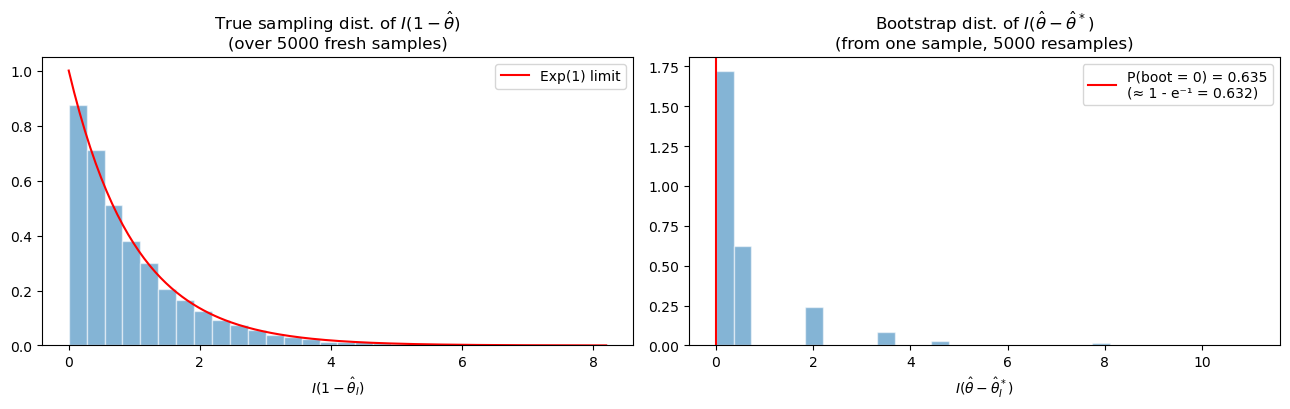

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
axes[0].hist(true_scaled,   bins=30, density=True, alpha=0.55, edgecolor='white')
xs = np.linspace(0, max(true_scaled.max(), 8), 200)
axes[0].plot(xs, stats.expon.pdf(xs), color='red', lw=1.5, label='Exp(1) limit')
axes[0].set_title(f'True sampling dist. of $I(1 - \\hat\\theta)$\n(over {M} fresh samples)')
axes[0].set_xlabel(r'$I(1 - \hat\theta_I)$'); axes[0].legend()

axes[1].hist(boot_scaled, bins=30, density=True, alpha=0.55, edgecolor='white')
axes[1].axvline(0, color='red', lw=1.5,
                label=f'P(boot = 0) = {p_zero:.3f}\n(≈ 1 - e⁻¹ = 0.632)')
axes[1].set_title(f'Bootstrap dist. of $I(\\hat\\theta - \\hat\\theta^*)$\n(from one sample, {M} resamples)')
axes[1].set_xlabel(r'$I(\hat\theta - \hat\theta_I^*)$'); axes[1].legend()
plt.tight_layout(); plt.show()


The bootstrap distribution sits a discrete atom at zero, with mass $\approx 0.63$: corresponding to bootstrap samples that happen to include the original maximum. The true sampling distribution is continuous (Exp(1) in the limit). The two are clearly *not* the same distribution, no matter how many bootstrap replications $B$ are taken.

## 6.1 Subsampling: a partial fix

When the bootstrap fails, the *subsampling* estimator of Politis, Romano, and Wolf (1999) often works: instead of resampling $I$ observations from $I$ with replacement, draw $m < I$ observations without replacement, with $m\to\infty$ and $m/I\to 0$. The subsampling distribution converges to the true sampling distribution under much weaker conditions, but the price is slower convergence and the need to choose $m$. We do not implement it here; the takeaway is that bootstrap failures should be expected for any estimator whose limiting distribution depends on extreme order statistics, parameter values on a boundary, or other nonregular features.

# 7. The structure of inference so far

Every estimator studied so far now has a second, simulation-based route to its sampling distribution. Let us summarize the structure of inference developed to this point.

**Asymptotic theory.** Lectures 1–4 developed the LLN/CLT/CMT/Slutsky toolkit and applied it to OLS, yielding the consistency and asymptotic normality results $\sqrt I(\hat\theta - \theta_0)\to\mathcal{N}(0, V)$ with $V$ a sandwich expression. Every subsequent estimator in the course, GLS and random effects (Lecture 5), panel FE (Lecture 7), MLE (Lecture 8), GMM (Lecture 9), IV (Lecture 10), DDML (Lecture 13), Heckman (Lecture 14), follows the same template: identify the population moment / likelihood, write the FOC, take a Taylor expansion, invoke LLN/CLT/Slutsky. The asymptotic variance is always a sandwich, and the SEs are always computable.

**Robust variance estimators.** Within this asymptotic framework, three variance estimators reappeared throughout: classical homoskedastic, Eicker–White heteroskedasticity-robust (HC0–HC3), and cluster-robust (CR1). Each is appropriate when the error structure satisfies its assumptions and overconservative or biased when those assumptions fail. Comparing the three helps identify which assumptions drive the reported uncertainty.

**The bootstrap.** Today's lecture introduced the bootstrap as a *simulation-based* alternative to the asymptotic theory. It is rarely strictly necessary, when the asymptotic theory works, it agrees with the bootstrap, but it is a useful check, and in some cases, multi-stage estimators, or statistics whose analytical variance is awkward, it gives more reliable coverage than a first-order approximation. The wild bootstrap, cluster bootstrap, and subsampling extend the basic idea to settings where i.i.d. resampling fails.

The bootstrap has two important limits. **Weak instruments** are not repaired by the ordinary pairs bootstrap: the problem there is that the asymptotic approximation itself fails, and resampling reproduces the same failed approximation rather than correcting it. The remedy is weak-instrument-robust inference, Anderson–Rubin or the conditional likelihood ratio, not a resampling scheme. And with **few clusters**, naive cluster resampling is not automatically attractive either: with $G$ small there are only so many distinct sets of clusters to draw, the bootstrap distribution becomes coarse, and the wild *cluster* bootstrap with Rademacher weights (Cameron, Gelbach and Miller 2008) is the procedure with the better small-$G$ record.

**What is still to come.** Lecture 13 introduces double/debiased machine learning, which is in some sense the *combination* of the asymptotic theory (Neyman-orthogonal score) with sample splitting (a close cousin of bootstrap). DDML combines classical asymptotic arguments with high-dimensional, machine-learning estimates of nuisance components.

The Mroz data has been our running example: 753 observations, a small set of variables, and a familiar selection problem. Applying each method to the same data makes the comparison transparent. We can see which assumptions change, how the estimates respond to alternative specifications, and what each estimator reveals in a given application.

# Looking ahead

Two lectures remain, and each relaxes something the preceding analysis has assumed.

* **Lecture 13 (double/debiased machine learning)** keeps the sandwich but stops insisting that the nuisance component be low-dimensional and parametric. Cross-fitting is the sample-splitting idea of this lecture put to a different purpose: not to approximate a sampling distribution, but to keep the error in an ML-estimated nuisance from contaminating the score.

* **Lecture 14 (limited dependent variables)** relaxes the assumption that the outcome is fully observed. Tobit and the Heckman correction buy identification back with a parametric assumption, joint normality, which is exactly the kind of assumption the bootstrap can probe but cannot repair.

The full source, and the broader `math+econ+code` series, which extends to matching, optimal transport, and discrete choice in greater depth, is at [github.com/math-econ-code/mec_notebooks](https://github.com/math-econ-code/mec_notebooks).